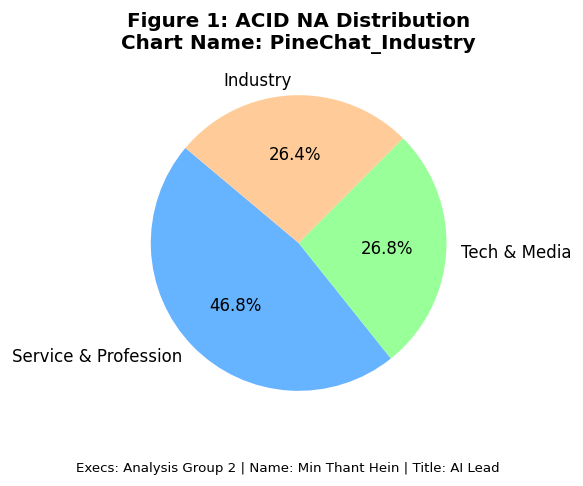

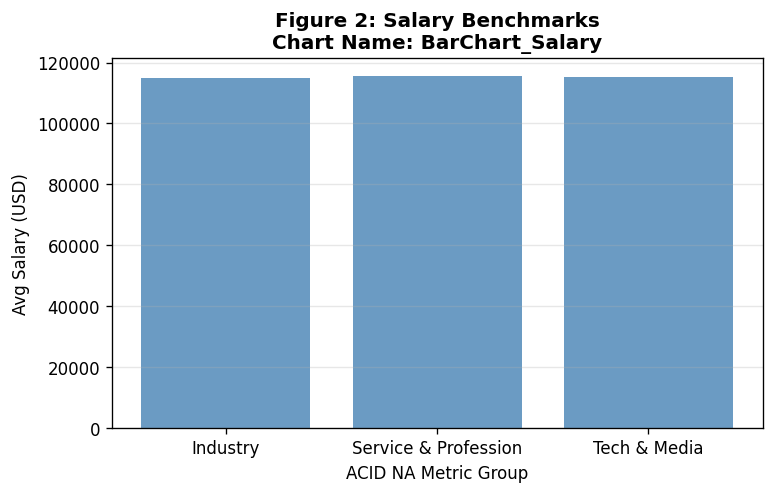

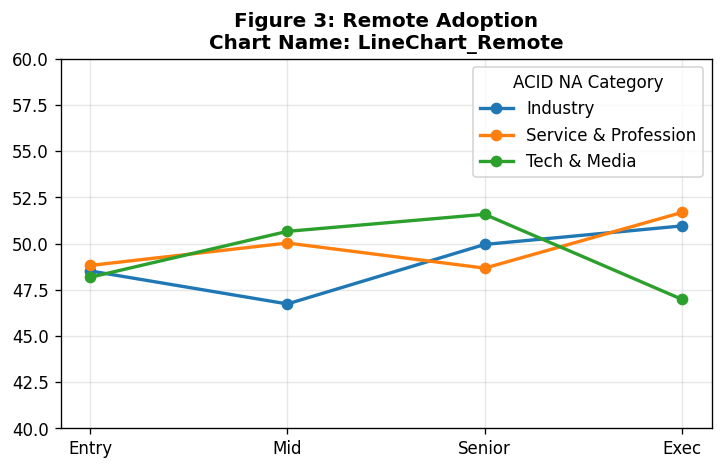

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os



# 0) Setup - Following professor's default display settings
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 120

# Load dataset
df = pd.read_csv('/content/ai_job_dataset.csv')

# Categorization for ACID NA Analysis
def map_category(industry):
    if industry in ['Technology', 'Media', 'Gaming', 'Telecommunications']:
        return 'Tech & Media'
    elif industry in ['Manufacturing', 'Energy', 'Automotive', 'Transportation']:
        return 'Industry'
    else:
        return 'Service & Profession'

df['Category'] = df['industry'].apply(map_category)

# Ensure output directory exists
os.makedirs("outputs", exist_ok=True)

# --- 1) PIE CHART (PineChat) ---
# Goal: Industry distribution
fig, ax = plt.subplots()
counts = df['Category'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
       colors=['#66b3ff','#99ff99','#ffcc99'])

# Labels & Title following professor's "Cross-check" requirements
ax.set_title("Figure 1: ACID NA Distribution\nChart Name: PineChat_Industry", fontweight='bold')
plt.gcf().text(0.5, 0.02, "Execs: Analysis Group 2 | Name: Min Thant Hein | Title: AI Lead", ha='center', fontsize=8)

fig.savefig("outputs/Figure1_Pie.pdf", format='pdf', dpi=300)

# --- 2) BAR CHART ---
# Goal: Salary comparison
fig, ax = plt.subplots()
salary_data = df.groupby('Category')['salary_usd'].mean()

ax.bar(salary_data.index, salary_data.values, color='steelblue', alpha=0.8)

# Styling based on Codelab (grid and axis labels)
ax.set_ylabel("Avg Salary (USD)")
ax.set_xlabel("ACID NA Metric Group")
ax.grid(True, axis='y', alpha=0.3)
ax.set_title("Figure 2: Salary Benchmarks\nChart Name: BarChart_Salary", fontweight='bold')

fig.savefig("outputs/Figure2_Bar.pdf", format='pdf', dpi=300)

# --- 3) LINE CHART ---
# Goal: Remote Work Trends
fig, ax = plt.subplots()
exp_order = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
df['exp_rank'] = df['experience_level'].map(exp_order)
trend = df.groupby(['exp_rank', 'Category'])['remote_ratio'].mean().unstack()

for col in trend.columns:
    ax.plot(['Entry', 'Mid', 'Senior', 'Exec'], trend[col], label=col, marker='o', linewidth=2)

# Customizing Axis Ticks and Legend as per Codelab
ax.set_ylim(40, 60)
ax.legend(title="ACID NA Category")
ax.grid(True, alpha=0.3)
ax.set_title("Figure 3: Remote Adoption\nChart Name: LineChart_Remote", fontweight='bold')

fig.savefig("outputs/Figure3_Line.pdf", format='pdf', dpi=300)

Market share? most?